In [50]:
#the model evaluation ends at downloading qwen2.5-7B model as the runtime ran out of disk space
#clearly bigger params model outperforms the lower one so will choose the 8b
#honestly it takes a lot of time so i give up

In [1]:
!pip install -q \
    "datasets==4.4.1" \
    "transformers==4.57.1" \
    "accelerate" \
    "bitsandbytes" \
    "qwen-vl-utils"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 45.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import torch
import random
import numpy as np

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

    props = torch.cuda.get_device_properties(0)

    print(
        "VRAM:",
        round(props.total_memory / 1024**3, 2),
        "GB"
    )

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 14.56 GB


In [3]:
import transformers
import datasets
import huggingface_hub

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("HuggingFace Hub:", huggingface_hub.__version__)

Transformers: 4.57.1
Datasets: 4.4.1
HuggingFace Hub: 0.36.2


In [4]:
questions_ds = load_dataset(
    "Rowan/vcr",
    "questions",
    split="train"
)

print(questions_ds)
print("Number of questions:", len(questions_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

questions/train-00000-of-00008.parquet:   0%|          | 0.00/76.3M [00:00<?, ?B/s]

questions/train-00001-of-00008.parquet:   0%|          | 0.00/76.8M [00:00<?, ?B/s]

...

questions/test-00007-of-00008.parquet:   0%|          | 0.00/8.97M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/212923 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/26534 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25263 [00:00<?, ? examples/s]

Dataset({
    features: ['movie', 'objects', 'interesting_scores', 'answer_likelihood', 'img_fn', 'metadata_fn', 'answer_orig', 'question_orig', 'rationale_orig', 'question_tokens', 'answer_choice_tokens', 'answer_label', 'answer_match_iter', 'answer_sources', 'rationale_choice_tokens', 'rationale_sources', 'rationale_match_iter', 'rationale_label', 'source_zip_crc_mismatch', 'img_id', 'question_number', 'annot_id', 'match_fold', 'match_index', 'question_text', 'answer_choice_texts', 'rationale_choice_texts'],
    num_rows: 212923
})
Number of questions: 212923


In [5]:
image_ds = load_dataset(
    "Rowan/vcr",
    "image_examples",
    split="train"
)

print(image_ds)
print("Number of images:", len(image_ds))

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

image_examples/train-00000-of-00059.parq(…):   0%|          | 0.00/446M [00:00<?, ?B/s]

image_examples/train-00001-of-00059.parq(…):   0%|          | 0.00/449M [00:00<?, ?B/s]

image_examples/train-00002-of-00059.parq(…):   0%|          | 0.00/452M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/80418 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9929 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9557 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/47 [00:00<?, ?it/s]

Dataset({
    features: ['image', 'img_fn', 'metadata_fn', 'movie', 'objects', 'width', 'height', 'image_width', 'image_height', 'boxes', 'segms_json', 'question_count', 'source_zip_crc_mismatch', 'image_metadata_dimension_mismatch', 'annotations'],
    num_rows: 80418
})
Number of images: 80418


In [6]:
!df -h /


Filesystem      Size  Used Avail Use% Mounted on
overlay         113G  108G  5.6G  96% /


In [7]:
!du -sh /root/.cache/* 2>/dev/null | sort -hr | head -20

60G	/root/.cache/huggingface
135M	/root/.cache/pip
56M	/root/.cache/node-gyp
36K	/root/.cache/matplotlib


In [8]:
!du -sh /root/.cache/huggingface/* 2>/dev/null

31G	/root/.cache/huggingface/datasets
30G	/root/.cache/huggingface/hub
35M	/root/.cache/huggingface/xet


In [9]:
!rm -rf /root/.cache/huggingface

In [10]:
!rm -rf /root/.cache/pip

In [11]:

!df -h /

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   72G   42G  64% /


In [12]:
image_index = {
    img_fn: i
    for i, img_fn in enumerate(image_ds["img_fn"])
}

print("Image index size:", len(image_index))

Image index size: 80418


In [13]:
q = questions_ds[0]

print("Question image:")
print(q["img_fn"])

image_idx = image_index[q["img_fn"]]

print("\nImage index:")
print(image_idx)

img = image_ds[image_idx]

print("\nMatched image:")
print(img["img_fn"])

assert q["img_fn"] == img["img_fn"]

print("\n✅ Question-image mapping works")

Question image:
lsmdc_3015_CHARLIE_ST_CLOUD/3015_CHARLIE_ST_CLOUD_00.23.57.935-00.24.00.783@0.jpg

Image index:
0

Matched image:
lsmdc_3015_CHARLIE_ST_CLOUD/3015_CHARLIE_ST_CLOUD_00.23.57.935-00.24.00.783@0.jpg

✅ Question-image mapping works


In [14]:
print("QUESTION:")
print(q["question_text"])

print("\nANSWERS:")

for i, answer in enumerate(q["answer_choice_texts"]):
    print(f"{i}: {answer}")

print("\nCORRECT ANSWER:")
print(q["answer_label"])

print("\nRATIONALES:")

for i, rationale in enumerate(q["rationale_choice_texts"]):
    print(f"{i}: {rationale}")

print("\nCORRECT RATIONALE:")
print(q["rationale_label"])

QUESTION:
Does [person2] feel comfortable?

ANSWERS:
0: Yes because the person sitting next to her is smiling.
1: No she does not.
2: Yes, she is wearing something with thin straps.
3: Yes, she is cold.

CORRECT ANSWER:
1

RATIONALES:
0: There is snow on the ground, and she is wearing a coat and hate.
1: She is standing with her arms crossed and looks disturbed.
2: She is sitting very rigidly and tensely on the edge of the bed. her posture is not relaxed and her face looks serious.
3: [person2] is laying in bed but not sleeping. she looks sad and is curled into a ball.

CORRECT RATIONALE:
1


In [15]:
print("OBJECTS:")

for i, obj in enumerate(img["objects"]):
    print(i, "->", obj)

print("\nBOXES:")

for i, box in enumerate(img["boxes"]):
    print(i, "->", box)

OBJECTS:
0 -> person
1 -> person
2 -> person
3 -> car

BOXES:
0 -> [953.9031982421875, 139.72866821289062, 1471.0701904296875, 768.2879638671875, 0.9985432624816895]
1 -> [657.2943725585938, 25.674560546875, 1062.8427734375, 745.1873168945312, 0.998895525932312]
2 -> [241.59446716308594, 54.851593017578125, 620.8653564453125, 700.7781982421875, 0.9988077878952026]
3 -> [2.4555816650390625, 331.0960693359375, 277.36383056640625, 579.8651733398438, 0.7267032265663147]


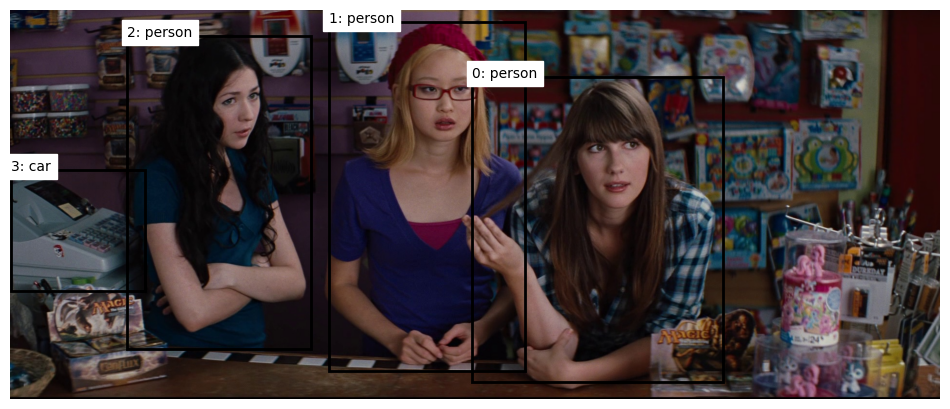

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image = img["image"]

fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(image)

for i, box in enumerate(img["boxes"]):

    x1, y1, x2, y2, conf = box

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        f"{i}: {img['objects'][i]}",
        fontsize=10,
        backgroundcolor="white"
    )

ax.axis("off")
plt.show()

In [17]:
def validate_sample(i):

    q = questions_ds[i]

    # Image exists
    if q["img_fn"] not in image_index:
        return False, "missing_image"

    # Exactly 4 answers
    if len(q["answer_choice_texts"]) != 4:
        return False, "bad_answers"

    # Valid answer label
    if q["answer_label"] not in [0, 1, 2, 3]:
        return False, "bad_answer_label"

    # Exactly 4 rationales
    if len(q["rationale_choice_texts"]) != 4:
        return False, "bad_rationales"

    # Valid rationale label
    if q["rationale_label"] not in [0, 1, 2, 3]:
        return False, "bad_rationale_label"

    return True, "valid"

In [18]:
sample_size = min(1000, len(questions_ds))

indices = random.sample(
    range(len(questions_ds)),
    sample_size
)

counts = {}

for i in indices:

    valid, reason = validate_sample(i)

    counts[reason] = counts.get(reason, 0) + 1

print(counts)

{'valid': 1000}


In [19]:
class VCRDataset(Dataset):

    def __init__(
        self,
        questions_ds,
        image_ds,
        image_index
    ):

        self.questions = questions_ds
        self.images = image_ds
        self.image_index = image_index

    def __len__(self):

        return len(self.questions)

    def __getitem__(self, idx):

        q = self.questions[idx]

        image_idx = self.image_index[q["img_fn"]]

        img = self.images[image_idx]

        return {

            # IMAGE
            "image": img["image"],
            "objects": img["objects"],
            "boxes": img["boxes"],

            # QUESTION
            "question": q["question_text"],

            # ANSWER
            "answers": q["answer_choice_texts"],
            "answer_label": q["answer_label"],

            # RATIONALE
            "rationales": q["rationale_choice_texts"],
            "rationale_label": q["rationale_label"],

            # IDs
            "img_fn": q["img_fn"],
            "img_id": q["img_id"]
        }

In [20]:
vcr_dataset = VCRDataset(
    questions_ds,
    image_ds,
    image_index
)

print("Dataset size:", len(vcr_dataset))

Dataset size: 212923


In [21]:
sample = vcr_dataset[0]

print(sample.keys())

dict_keys(['image', 'objects', 'boxes', 'question', 'answers', 'answer_label', 'rationales', 'rationale_label', 'img_fn', 'img_id'])


In [22]:
print("QUESTION:")
print(sample["question"])

print("\nANSWERS:")

for i, answer in enumerate(sample["answers"]):
    print(f"{i}: {answer}")

print("\nCORRECT ANSWER:", sample["answer_label"])

print("\nRATIONALES:")

for i, rationale in enumerate(sample["rationales"]):
    print(f"{i}: {rationale}")

print("\nCORRECT RATIONALE:", sample["rationale_label"])

print("\nIMAGE:", sample["img_fn"])

QUESTION:
Does [person2] feel comfortable?

ANSWERS:
0: Yes because the person sitting next to her is smiling.
1: No she does not.
2: Yes, she is wearing something with thin straps.
3: Yes, she is cold.

CORRECT ANSWER: 1

RATIONALES:
0: There is snow on the ground, and she is wearing a coat and hate.
1: She is standing with her arms crossed and looks disturbed.
2: She is sitting very rigidly and tensely on the edge of the bed. her posture is not relaxed and her face looks serious.
3: [person2] is laying in bed but not sleeping. she looks sad and is curled into a ball.

CORRECT RATIONALE: 1

IMAGE: lsmdc_3015_CHARLIE_ST_CLOUD/3015_CHARLIE_ST_CLOUD_00.23.57.935-00.24.00.783@0.jpg


In [23]:
def vcr_collate_fn(batch):

    return {

        "images": [
            item["image"]
            for item in batch
        ],

        "objects": [
            item["objects"]
            for item in batch
        ],

        "boxes": [
            item["boxes"]
            for item in batch
        ],

        "questions": [
            item["question"]
            for item in batch
        ],

        "answers": [
            item["answers"]
            for item in batch
        ],

        "answer_labels": torch.tensor(
            [
                item["answer_label"]
                for item in batch
            ],
            dtype=torch.long
        ),

        "rationales": [
            item["rationales"]
            for item in batch
        ],

        "rationale_labels": torch.tensor(
            [
                item["rationale_label"]
                for item in batch
            ],
            dtype=torch.long
        ),

        "img_fn": [
            item["img_fn"]
            for item in batch
        ],

        "img_id": [
            item["img_id"]
            for item in batch
        ]
    }

In [24]:
vcr_loader = DataLoader(
    vcr_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=vcr_collate_fn
)

print("DataLoader created")

DataLoader created


In [25]:
batch = next(iter(vcr_loader))

print(batch.keys())

dict_keys(['images', 'objects', 'boxes', 'questions', 'answers', 'answer_labels', 'rationales', 'rationale_labels', 'img_fn', 'img_id'])


In [26]:
print("Images:", len(batch["images"]))

print("\nQUESTION:")
print(batch["questions"][0])

print("\nANSWERS:")

for i, answer in enumerate(batch["answers"][0]):
    print(f"{i}: {answer}")

print("\nCORRECT ANSWER:")
print(batch["answer_labels"][0].item())

print("\nRATIONALES:")

for i, rationale in enumerate(batch["rationales"][0]):
    print(f"{i}: {rationale}")

print("\nCORRECT RATIONALE:")
print(batch["rationale_labels"][0].item())

Images: 1

QUESTION:
What room are [person0,person1] walking through together?

ANSWERS:
0: It looks like a bathroom.
1: They are in a break room.
2: They are walking back to work together.
3: An office of a newsroom.

CORRECT ANSWER:
1

RATIONALES:
0: The wall tile is like that in a bathroom and there is a hand dryer on one wall.
1: This room looks like a break room for some kind of business.
2: Break rooms have refrigerators coffee pots and there are a lot of cups and in the back indicating a lot of people use this room it' s not in the home.
3: There are large signs saying daybreak, and a wall with daybreak wallpaper. [person0,person1] are professionally dressed.

CORRECT RATIONALE:
2


In [30]:
# CELL 25

!pip uninstall -y transformers tokenizers huggingface-hub -q

!pip install -q \
    "huggingface-hub>=0.34.0,<1.0" \
    "transformers>=4.57.0" \
    "tokenizers>=0.22.0" \
    accelerate \
    bitsandbytes \
    qwen-vl-utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 113.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [31]:

import os
import gc
import re
import json
import time
import random

import torch
import pandas as pd

from PIL import Image

from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen3VLForConditionalGeneration,
    Qwen2_5_VLForConditionalGeneration
)

In [32]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [33]:
NUM_SAMPLES = 100
SEED = 42

random.seed(SEED)

sample_indices = random.sample(
    range(len(vcr_dataset)),
    NUM_SAMPLES
)

print("Number of samples:", len(sample_indices))
print("First 10 indices:", sample_indices[:10])

Number of samples: 100
First 10 indices: [167621, 29184, 6556, 194393, 72097, 64196, 58513, 36579, 193061, 26868]


In [34]:
# CELL 29

MODELS = {

    "qwen3-vl-2b": {
        "name": "Qwen/Qwen3-VL-2B-Instruct",
        "type": "qwen3"
    },

    "qwen3-vl-4b": {
        "name": "Qwen/Qwen3-VL-4B-Instruct",
        "type": "qwen3"
    },

    "qwen3-vl-8b": {
        "name": "Qwen/Qwen3-VL-8B-Instruct",
        "type": "qwen3"
    },

    "qwen2.5vl-3b": {
        "name": "Qwen/Qwen2.5-VL-3B-Instruct",
        "type": "qwen25"
    },

    "qwen2.5vl-7b": {
        "name": "Qwen/Qwen2.5-VL-7B-Instruct",
        "type": "qwen25"
    }
}

print(*MODELS.keys(), sep="\n")

qwen3-vl-2b
qwen3-vl-4b
qwen3-vl-8b
qwen2.5vl-3b
qwen2.5vl-7b


In [ ]:
print(
    "Model device:",
    next(model.parameters()).device
)

Model device: cuda:0


In [35]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("4-bit quantization configured.")

4-bit quantization configured.


In [36]:
def load_model(model_name, model_type):

    print("=" * 70)
    print("LOADING:", model_name)
    print("=" * 70)

    if model_type == "qwen3":

        processor = AutoProcessor.from_pretrained(
            model_name,
            trust_remote_code=True
        )

        model = Qwen3VLForConditionalGeneration.from_pretrained(
            model_name,
            quantization_config=quantization_config,
            device_map="auto",
            torch_dtype=torch.float16,
            trust_remote_code=True
        )

    elif model_type == "qwen25":

        processor = AutoProcessor.from_pretrained(
            model_name,
            trust_remote_code=True
        )

        model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            model_name,
            quantization_config=quantization_config,
            device_map="auto",
            torch_dtype=torch.float16,
            trust_remote_code=True
        )

    else:
        raise ValueError("Unknown model type")

    model.eval()

    print("✅ Model loaded")

    return model, processor

In [37]:
def make_answer_prompt(question, answers):

    return f"""
You are solving a Visual Commonsense Reasoning (VCR) multiple-choice question.

Look carefully at the image.

Question:
{question}

Answer choices:

0. {answers[0]}

1. {answers[1]}

2. {answers[2]}

3. {answers[3]}

Choose the single best answer.

Return ONLY the number:
0, 1, 2, or 3.
"""

In [38]:
def make_rationale_prompt(
    question,
    selected_answer,
    answer_text,
    rationales
):

    return f"""
You are solving a Visual Commonsense Reasoning (VCR) question.

Look carefully at the image.

Question:
{question}

Selected answer:
{selected_answer}. {answer_text}

Choose the single best rationale explaining why
the selected answer is correct.

Rationale choices:

0. {rationales[0]}

1. {rationales[1]}

2. {rationales[2]}

3. {rationales[3]}

Return ONLY the number:
0, 1, 2, or 3.
"""

In [39]:
def extract_choice(text):

    if text is None:
        return -1

    text = text.strip()

    # Prefer a standalone 0-3
    match = re.search(r"\b([0-3])\b", text)

    if match:
        return int(match.group(1))

    return -1

In [40]:
def generate_response(
    model,
    processor,
    image,
    prompt
):

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    # Move tensors to model device
    inputs = {
        k: v.to(model.device)
        if torch.is_tensor(v)
        else v
        for k, v in inputs.items()
    }

    with torch.inference_mode():

        generated_ids = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False
        )

    # Remove input tokens
    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids
        in zip(
            inputs["input_ids"],
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text

In [41]:
test_idx = sample_indices[0]

sample = vcr_dataset[test_idx]

image = sample["image"]
question = sample["question"]
answers = sample["answers"]

print("Question:")
print(question)

print("\nAnswers:")
for i, answer in enumerate(answers):
    print(i, answer)

Question:
Why is [person0] smiling at [person1]?

Answers:
0 He is glad that [person1] is going first.
1 Because he said something funny.
2 He is really happy to see her.
3 [person0] is wanting [person1] to enjoy his celebration.


In [42]:
TEST_MODEL = MODELS["qwen3-vl-2b"]

model, processor = load_model(
    TEST_MODEL["name"],
    TEST_MODEL["type"]
)

LOADING: Qwen/Qwen3-VL-2B-Instruct


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

✅ Model loaded


In [43]:
prompt = make_answer_prompt(
    question,
    answers
)

output = generate_response(
    model,
    processor,
    image,
    prompt
)

print("RAW MODEL OUTPUT:")
print(output)

print("\nEXTRACTED ANSWER:")
print(extract_choice(output))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


RAW MODEL OUTPUT:
2

EXTRACTED ANSWER:
2


In [44]:

predicted_answer = extract_choice(output)

rationales = sample["rationales"]

rationale_prompt = make_rationale_prompt(
    question,
    predicted_answer,
    answers[predicted_answer],
    rationales
)

rationale_output = generate_response(
    model,
    processor,
    image,
    rationale_prompt
)

print("RAW RATIONALE OUTPUT:")
print(rationale_output)

print("\nEXTRACTED RATIONALE:")
print(extract_choice(rationale_output))

RAW RATIONALE OUTPUT:
0

EXTRACTED RATIONALE:
0


In [45]:
del model
del processor

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("GPU memory cleared.")

GPU memory cleared.


In [46]:
def evaluate_model(
    model,
    processor,
    model_label,
    sample_indices
):

    results = []

    start_time = time.time()

    total = len(sample_indices)

    print("\n")
    print("=" * 80)
    print("STARTING:", model_label)
    print("SAMPLES:", total)
    print("=" * 80)

    for count, idx in enumerate(sample_indices, start=1):

        sample = vcr_dataset[idx]

        image = sample["image"]

        question = sample["question"]
        answers = sample["answers"]
        rationales = sample["rationales"]

        true_answer = int(
            sample["answer_label"]
        )

        true_rationale = int(
            sample["rationale_label"]
        )

        # ======================================
        # STAGE 1
        # ======================================

        answer_prompt = make_answer_prompt(
            question,
            answers
        )

        try:

            answer_raw = generate_response(
                model,
                processor,
                image,
                answer_prompt
            )

            predicted_answer = extract_choice(
                answer_raw
            )

        except Exception as e:

            answer_raw = f"ERROR: {str(e)}"
            predicted_answer = -1


        # ======================================
        # STAGE 2
        # ======================================

        if predicted_answer in [0, 1, 2, 3]:

            rationale_prompt = make_rationale_prompt(
                question,
                predicted_answer,
                answers[predicted_answer],
                rationales
            )

            try:

                rationale_raw = generate_response(
                    model,
                    processor,
                    image,
                    rationale_prompt
                )

                predicted_rationale = extract_choice(
                    rationale_raw
                )

            except Exception as e:

                rationale_raw = f"ERROR: {str(e)}"
                predicted_rationale = -1

        else:

            rationale_raw = "SKIPPED"
            predicted_rationale = -1


        # ======================================
        # METRICS
        # ======================================

        answer_correct = (
            predicted_answer == true_answer
        )

        rationale_correct = (
            predicted_rationale == true_rationale
        )

        joint_correct = (
            answer_correct
            and rationale_correct
        )


        # ======================================
        # SAVE RESULT
        # ======================================

        results.append({

            "model": model_label,

            "sample_index": idx,

            "img_fn": sample["img_fn"],

            "question": question,

            "predicted_answer":
                predicted_answer,

            "true_answer":
                true_answer,

            "predicted_rationale":
                predicted_rationale,

            "true_rationale":
                true_rationale,

            "answer_correct":
                answer_correct,

            "rationale_correct":
                rationale_correct,

            "joint_correct":
                joint_correct,

            "answer_raw_output":
                answer_raw,

            "rationale_raw_output":
                rationale_raw
        })


        # ======================================
        # PROGRESS
        # ======================================

        print(
            f"[{count:3d}/{total}] "
            f"A: {predicted_answer}/{true_answer} "
            f"R: {predicted_rationale}/{true_rationale} "
            f"| Joint: {joint_correct}"
        )


    elapsed = time.time() - start_time

    df = pd.DataFrame(results)

    summary = {

        "model": model_label,

        "samples": len(df),

        "answer_accuracy":
            df["answer_correct"].mean(),

        "rationale_accuracy":
            df["rationale_correct"].mean(),

        "joint_accuracy":
            df["joint_correct"].mean(),

        "invalid_answers":
            (df["predicted_answer"] == -1).sum(),

        "invalid_rationales":
            (df["predicted_rationale"] == -1).sum(),

        "total_time_seconds":
            elapsed,

        "seconds_per_sample":
            elapsed / len(df)
    }

    return df, summary

In [47]:
RESULTS_DIR = "vcr_model_results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

print("Results will be saved to:", RESULTS_DIR)

Results will be saved to: vcr_model_results


In [48]:
all_summaries = []


for model_label, config in MODELS.items():

    print("\n\n")
    print("#" * 90)
    print("#")
    print("# MODEL:", model_label)
    print("#")
    print("#" * 90)


    # ==========================================
    # LOAD
    # ==========================================

    model, processor = load_model(
        config["name"],
        config["type"]
    )


    # ==========================================
    # RUN 100
    # ==========================================

    results_df, summary = evaluate_model(
        model=model,
        processor=processor,
        model_label=model_label,
        sample_indices=sample_indices
    )


    # ==========================================
    # SAVE RAW RESULTS
    # ==========================================

    result_path = os.path.join(
        RESULTS_DIR,
        f"{model_label}_100_results.csv"
    )

    results_df.to_csv(
        result_path,
        index=False
    )


    # ==========================================
    # SAVE SUMMARY
    # ==========================================

    all_summaries.append(summary)

    summary_df = pd.DataFrame(
        all_summaries
    )

    summary_df.to_csv(
        os.path.join(
            RESULTS_DIR,
            "summary.csv"
        ),
        index=False
    )


    # ==========================================
    # PRINT RESULT
    # ==========================================

    print("\n")
    print("=" * 70)
    print("RESULT:", model_label)
    print("=" * 70)

    print(
        f"Answer Accuracy    : "
        f"{summary['answer_accuracy']:.2%}"
    )

    print(
        f"Rationale Accuracy : "
        f"{summary['rationale_accuracy']:.2%}"
    )

    print(
        f"Joint Accuracy     : "
        f"{summary['joint_accuracy']:.2%}"
    )

    print(
        f"Invalid Answers    : "
        f"{summary['invalid_answers']}"
    )

    print(
        f"Invalid Rationales : "
        f"{summary['invalid_rationales']}"
    )

    print(
        f"Time               : "
        f"{summary['total_time_seconds']:.1f}s"
    )

    print(
        f"Time/sample        : "
        f"{summary['seconds_per_sample']:.2f}s"
    )


    # ==========================================
    # DELETE MODEL FROM RAM
    # ==========================================

    del model
    del processor

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


    print("\n✅ Model unloaded:", model_label)




##########################################################################################
#
# MODEL: qwen3-vl-2b
#
##########################################################################################
LOADING: Qwen/Qwen3-VL-2B-Instruct
✅ Model loaded


STARTING: qwen3-vl-2b
SAMPLES: 100
[  1/100] A: 2/2 R: 0/3 | Joint: False
[  2/100] A: 1/1 R: 1/1 | Joint: True
[  3/100] A: 1/1 R: 3/3 | Joint: True
[  4/100] A: 2/2 R: 1/1 | Joint: True
[  5/100] A: 3/2 R: 1/1 | Joint: False
[  6/100] A: 3/3 R: 0/0 | Joint: True
[  7/100] A: 0/0 R: 0/0 | Joint: True
[  8/100] A: 1/1 R: 3/3 | Joint: True
[  9/100] A: 3/0 R: 3/3 | Joint: False
[ 10/100] A: 0/1 R: 0/1 | Joint: False
[ 11/100] A: 0/2 R: 3/3 | Joint: False
[ 12/100] A: 3/3 R: 0/0 | Joint: True
[ 13/100] A: 2/3 R: 2/2 | Joint: False
[ 14/100] A: 3/0 R: 2/2 | Joint: False
[ 15/100] A: 0/1 R: 0/2 | Joint: False
[ 16/100] A: 2/2 R: 0/0 | Joint: True
[ 17/100] A: 0/0 R: 2/2 | Joint: True
[ 18/100] A: 1/1 R: 3/3 | Joint: True
[ 19/100] A

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00004-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

model-00002-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00001-of-00005.safetensors:   0%|          | 0.00/3.90G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [49]:
final_results = pd.DataFrame(
    all_summaries
)

final_results = final_results.sort_values(
    "joint_accuracy",
    ascending=False
).reset_index(drop=True)

display(final_results)

,model,samples,answer_accuracy,rationale_accuracy,joint_accuracy,invalid_answers,invalid_rationales,total_time_seconds,seconds_per_sample
0,qwen3-vl-8b,100,0.75,0.67,0.53,0,0,752.254936,7.522549
1,qwen3-vl-4b,100,0.73,0.58,0.47,0,0,540.005493,5.400055
2,qwen2.5vl-3b,100,0.61,0.60,0.41,4,4,580.051836,5.800518
3,qwen3-vl-2b,100,0.58,0.52,0.33,0,0,306.878860,3.068789
